In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
file_path = r"C:\Users\91988\Desktop\Christ University(SEM 4 MCA)\Data Engineering\Teen_Mental_Health_Dataset_all_column (1).csv"
df = pd.read_csv(file_path)

In [5]:
print("First 10 rows:")
print(df.head(10))
print(f"\nDataset shape: {df.shape}")

First 10 rows:
    age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0  14.0     NaN                       7.9      Instagram          7.4   
1  19.0  female                       1.9         TikTok          8.0   
2  17.0  female                       1.3      Instagram          7.6   
3  15.0    male                       7.4         TikTok          6.9   
4  15.0  female                       NaN           Both          4.9   
5   NaN  female                       7.4           Both          4.4   
6  18.0  female                       2.5      Instagram          6.4   
7  16.0    male                       4.0           Both          4.2   
8  19.0  female                       3.3         TikTok          5.0   
9  15.0    male                       1.9         TikTok          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9          

In [6]:

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical Variables: {numerical_cols}")
print(f"Categorical Variables: {categorical_cols}")


print("\nColumn Data Types:")
print(df.dtypes)

Numerical Variables: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Categorical Variables: ['gender', 'platform_usage', 'social_interaction_level']

Column Data Types:
age                         float64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                float64
anxiety_level               float64
addiction_level             float64
depression_label            float64
dtype: object


In [7]:

stats = df.describe()
display(stats)
variation = df[numerical_cols].std().idxmax()
print(f"Variable having the highest variation{variation}")

sm_mean = df['daily_social_media_hours'].mean()
sm_median = df['daily_social_media_hours'].median()
sleep_mean = df['sleep_hours'].mean()
sleep_median = df['sleep_hours'].median()

print(f"\nSocial Media - Mean: {sm_mean:.2f}, Median: {sm_median:.2f}")
print(f"Sleep Hours - Mean: {sleep_mean:.2f}, Median: {sleep_median:.2f}")

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1105.000000,1056.000000,1008.000000,1140.000000,1080.000000,1092.000000,1092.000000,1092.000000,1128.000000,1008.000000
mean,15.901357,4.544129,6.443155,1.735965,2.986148,1.016392,5.454212,5.608974,5.572695,0.025794
std,2.016294,2.027443,1.457104,0.717721,0.578481,0.581912,2.898641,2.851348,2.836578,0.158598
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.100000,1.100000,2.490000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.400000,1.700000,2.980000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.700000,2.325000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


Variable having the highest variationstress_level

Social Media - Mean: 4.54, Median: 4.50
Sleep Hours - Mean: 6.44, Median: 6.40


In [19]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_percentage})
print("Missing Values")
display(missing_df[missing_df['Missing Count'] > 0])

Missing Values


,Missing Count,Percentage (%)
age,95,7.916667
gender,228,19.000000
daily_social_media_hours,144,12.000000
platform_usage,168,14.000000
sleep_hours,192,16.000000
screen_time_before_sleep,60,5.000000
academic_performance,120,10.000000
physical_activity,108,9.000000
social_interaction_level,168,14.000000
stress_level,108,9.000000


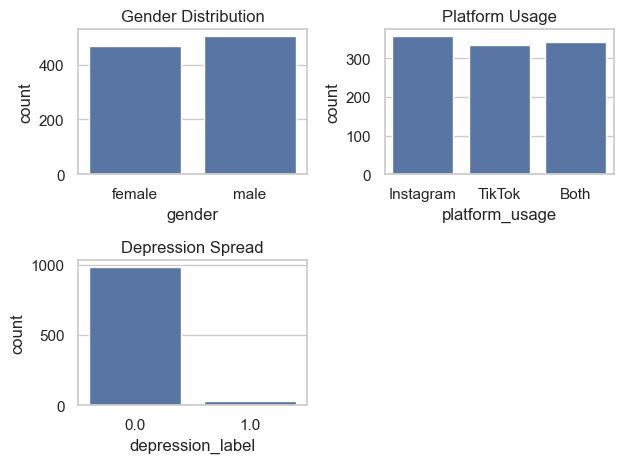

In [28]:
# a.
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='platform_usage')
plt.title('Platform Usage')

plt.subplot(2, 2, 3)
sns.countplot(data=df, x='depression_label')
plt.title('Depression Spread')
plt.tight_layout()
plt.show()

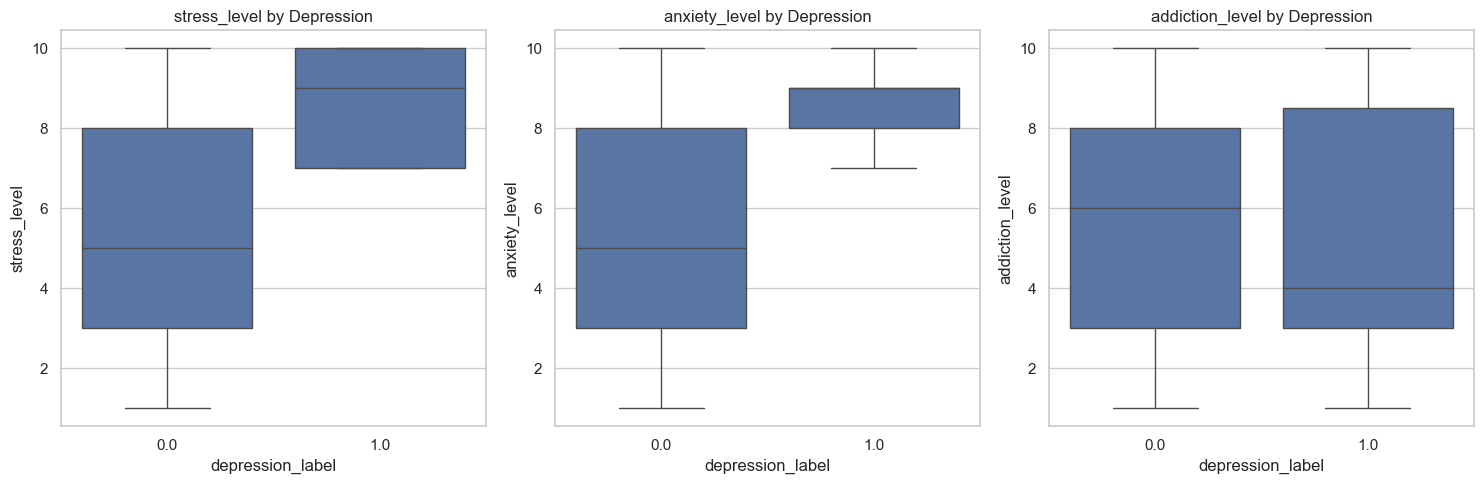

In [31]:
# b
plt.figure(figsize=(15, 5))
for i, col in enumerate(['stress_level', 'anxiety_level', 'addiction_level']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='depression_label', y=col, data=df)
    plt.title(f'{col} by Depression')
plt.tight_layout()
plt.show()



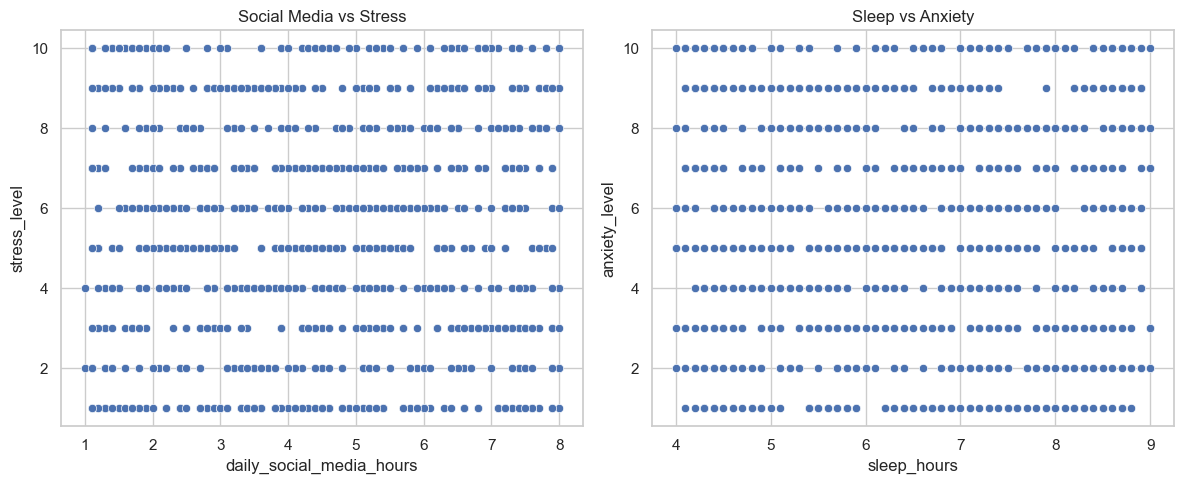

In [22]:
# c
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='daily_social_media_hours', y='stress_level')
plt.title('Social Media vs Stress')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='sleep_hours', y='anxiety_level')
plt.title('Sleep vs Anxiety')
plt.tight_layout()
plt.show()

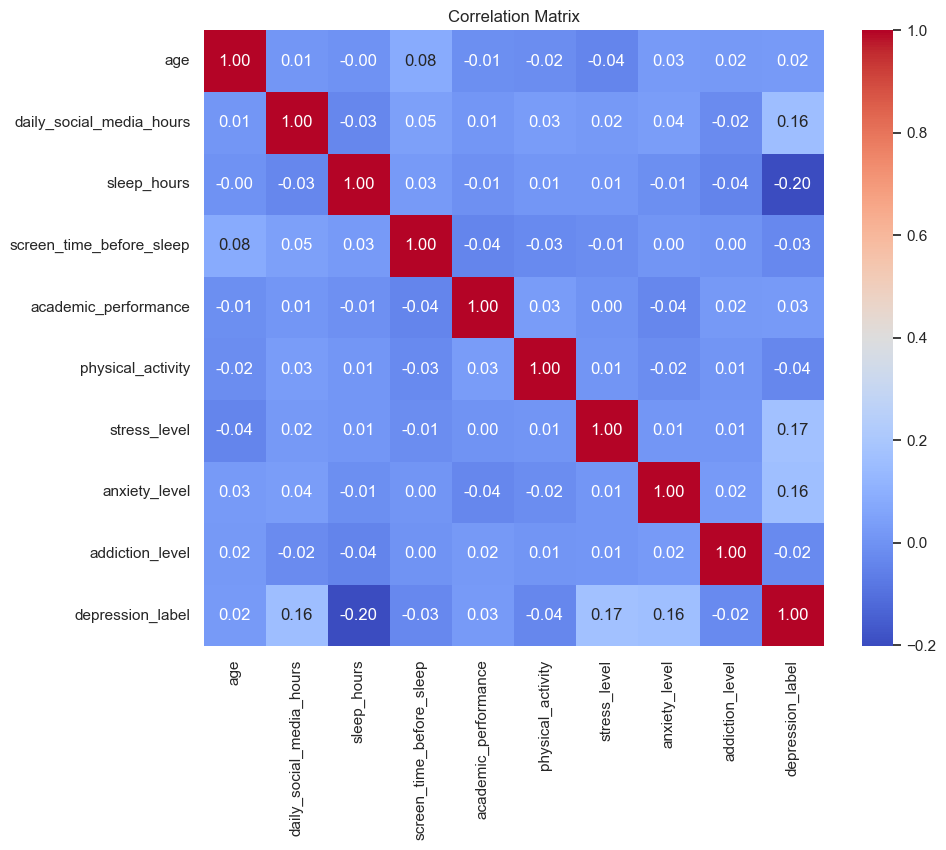

In [29]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [24]:
outlier_cols = ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} outliers.")

3.5
daily_social_media_hours: Found 0 outliers.
2.6000000000000005
sleep_hours: Found 0 outliers.
5.0
stress_level: Found 0 outliers.
5.0
anxiety_level: Found 0 outliers.


In [30]:
print(f"\nDataset shape: {df.describe}")


Dataset shape: <bound method NDFrame.describe of        age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0     14.0     NaN                       7.9      Instagram          7.4   
1     19.0  female                       1.9         TikTok          8.0   
2     17.0  female                       1.3      Instagram          7.6   
3     15.0    male                       7.4         TikTok          6.9   
4     15.0  female                       NaN           Both          4.9   
...    ...     ...                       ...            ...          ...   
1195  18.0  female                       6.8      Instagram          6.6   
1196  16.0    male                       2.3           Both          8.0   
1197  14.0  female                       1.7           Both          8.7   
1198  15.0    male                       NaN           Both          8.5   
1199  16.0     NaN                       4.7         TikTok          6.5   

      screen_time_before_sleep  acade